# Ejercicio 6 - Criterio de Nyquist, mascaras y canal no ideal

El canal tiene la siguiente respuesta en frecuencia:

$$H_c(f)=\begin{cases}
1, & |f|<4\;\text{MHz} \\
0.5, & 4\;\text{MHz}<|f|<5\;\text{MHz} \\
0, & |f|>5\;\text{MHz}
\end{cases}$$

Se desea transmitir utilizando un filtro coseno realzado con:

$$\beta=0.35$$

Se pide:

1. La maxima tasa de simbolos libre de ISI.
2. Si existe distorsion lineal.
3. Como modificar el receptor para compensarla.

## Idea de mascaras

Cuando el profesor habla de **mascaras**, se refiere a comparar dos formas en frecuencia:

- La mascara del canal: indica que frecuencias pasan y con que ganancia.
- La mascara de la senal transmitida: indica que ancho de banda ocupa el filtro coseno realzado.

Para que la senal no pierda componentes espectrales, la mascara del coseno realzado debe entrar dentro de la zona donde el canal no es cero. En este canal, la zona no nula llega hasta `5 MHz`.

Pero hay otro detalle: entre `4 MHz` y `5 MHz`, el canal no corta la senal, pero la atenúa a la mitad. Eso no es perdida total de banda, pero si es **distorsion lineal**, porque el canal no multiplica todas las frecuencias por la misma constante.

## Ancho de banda del coseno realzado

Para un filtro coseno realzado con factor de roll-off `beta`, el ancho de banda positivo ocupado es:

$$B=\frac{(1+\beta)R_s}{2}$$

Si conocemos el ancho de banda disponible y queremos despejar la maxima tasa de simbolos:

$$R_s=\frac{2B}{1+\beta}$$

Como el canal es no nulo hasta `5 MHz`, la maxima tasa de simbolos que entra dentro de la mascara no nula del canal se obtiene usando:

$$B=5\;\text{MHz}$$

In [1]:
import numpy as np
import matplotlib.pyplot as plt

beta = 0.35
B_no_nulo = 5e6  # Hz, el canal existe hasta |f| = 5 MHz
B_plano = 4e6    # Hz, el canal es plano hasta |f| = 4 MHz

Rs_max = 2 * B_no_nulo / (1 + beta)
Rs_sin_distorsion = 2 * B_plano / (1 + beta)

print(f"beta = {beta}")
print(f"Rs maxima usando toda la banda no nula hasta 5 MHz = {Rs_max/1e6:.4f} Msimb/s")
print(f"Rs si solo usamos la zona plana hasta 4 MHz = {Rs_sin_distorsion/1e6:.4f} Msimb/s")

beta = 0.35
Rs maxima usando toda la banda no nula hasta 5 MHz = 7.4074 Msimb/s
Rs si solo usamos la zona plana hasta 4 MHz = 5.9259 Msimb/s


# Punto 1 - Maxima tasa de simbolos libre de ISI

Usando toda la zona donde el canal no es cero, el maximo ancho de banda positivo disponible es:

$$B=5\;\text{MHz}$$

Entonces:

$$R_s=\frac{2B}{1+\beta}$$

$$R_s=\frac{2(5\times10^6)}{1+0.35}$$

$$R_s=\frac{10\times10^6}{1.35}$$

$$R_s\approx 7.407\times10^6\;\text{simbolos/s}$$

Por lo tanto:

$$R_{s,max}\approx 7.407\;\text{Msimb/s}$$

Esta tasa es la maxima si luego se compensa la distorsion lineal del canal. La senal entra dentro de la banda no nula del canal, pero una parte cae en la zona de atenuacion entre `4 MHz` y `5 MHz`.

## Caso conservador sin ecualizacion

Si se quisiera evitar cualquier distorsion lineal sin modificar el receptor, habria que limitar el espectro a la parte plana del canal:

$$B=4\;\text{MHz}$$

Entonces:

$$R_s=\frac{2(4\times10^6)}{1+0.35}\approx 5.926\;\text{Msimb/s}$$

Este valor es menor porque no se aprovecha la banda entre `4 MHz` y `5 MHz`. Sin embargo, en esa condicion el canal actua como una ganancia constante sobre todo el espectro usado, por lo que no introduce distorsion lineal de amplitud.

# Punto 2 - Si existe distorsion lineal

Si usamos la tasa maxima `Rs = 7.407 Msimb/s`, el ancho de banda ocupado por el coseno realzado llega hasta `5 MHz`. Eso significa que parte del espectro cae en la zona:

$$4\;\text{MHz}<|f|<5\;\text{MHz}$$

En esa zona el canal tiene ganancia `0.5`, mientras que para `|f|<4 MHz` tiene ganancia `1`.

Por lo tanto, **si existe distorsion lineal**: las componentes de frecuencia no son amplificadas o atenuadas todas por igual. Las frecuencias entre `4 MHz` y `5 MHz` llegan con la mitad de amplitud que las frecuencias menores a `4 MHz`.

Esto se llama lineal porque el canal sigue siendo un sistema lineal e invariante en el tiempo, pero es distorsivo porque su respuesta en frecuencia no es plana en toda la banda usada por la senal.

# Punto 3 - Como modificar el receptor para compensarla

Para compensar la distorsion lineal se agrega un **ecualizador** en el receptor. La idea del ecualizador es aplicar la inversa del canal dentro de la banda utilizada:

$$H_{eq}(f)=\frac{1}{H_c(f)}$$

En este caso:

$$H_{eq}(f)=\begin{cases}
1, & |f|<4\;\text{MHz} \\
2, & 4\;\text{MHz}<|f|<5\;\text{MHz}
\end{cases}$$

La razon es simple: si el canal multiplica por `0.5` en la zona entre `4 MHz` y `5 MHz`, el ecualizador multiplica por `2` para recuperar la amplitud original.

En un sistema con filtros raiz coseno realzado, esto puede verse como:

$$H_{total}(f)=H_{Tx}(f)H_c(f)H_{eq}(f)H_{Rx}(f)$$

Si `H_eq(f)=1/H_c(f)` en la banda usada, entonces:

$$H_c(f)H_{eq}(f)=1$$

y queda la respuesta deseada de Nyquist:

$$H_{total}(f)=H_{Tx}(f)H_{Rx}(f)$$

Si `Tx` y `Rx` son raiz coseno realzado, su producto forma un coseno realzado total, que cumple el criterio de Nyquist.

Aclaracion practica: esta compensacion se llama ecualizacion de cero forzado. Si hubiera mucho ruido, amplificar por `2` tambien amplificaria el ruido en esa banda. En ese caso podria convenir un ecualizador MMSE, pero para el planteo ideal del ejercicio alcanza con indicar el inverso del canal.

## Grafica de mascaras

La siguiente grafica compara la mascara del canal con el ancho ocupado por el coseno realzado cuando se usa la tasa maxima calculada. La senal entra hasta `5 MHz`, pero toca la zona atenuada del canal.

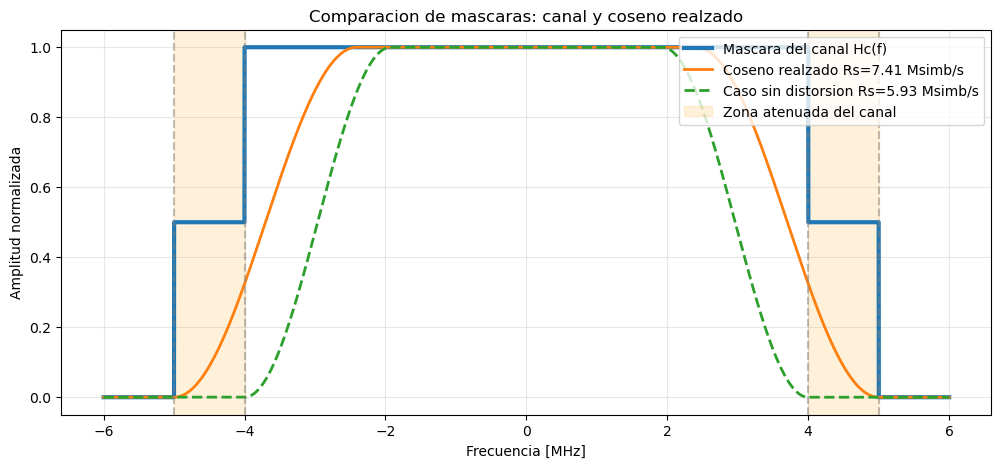

In [2]:
def canal_H(f):
    f_abs = np.abs(f)
    H = np.zeros_like(f_abs, dtype=float)
    H[f_abs < 4e6] = 1.0
    H[(f_abs >= 4e6) & (f_abs < 5e6)] = 0.5
    return H

def raised_cosine_spectrum(f, Rs, beta):
    f_abs = np.abs(f)
    H = np.zeros_like(f_abs, dtype=float)
    f1 = (1 - beta) * Rs / 2
    f2 = (1 + beta) * Rs / 2

    H[f_abs <= f1] = 1.0
    transicion = (f_abs > f1) & (f_abs <= f2)
    H[transicion] = 0.5 * (1 + np.cos(np.pi / (beta * Rs) * (f_abs[transicion] - f1)))
    return H

f = np.linspace(-6e6, 6e6, 6000)
Hc = canal_H(f)
Hrc_max = raised_cosine_spectrum(f, Rs_max, beta)
Hrc_plano = raised_cosine_spectrum(f, Rs_sin_distorsion, beta)

plt.figure(figsize=(12, 5))
plt.plot(f/1e6, Hc, linewidth=3, label="Mascara del canal Hc(f)")
plt.plot(f/1e6, Hrc_max, linewidth=2, label=f"Coseno realzado Rs={Rs_max/1e6:.2f} Msimb/s")
plt.plot(f/1e6, Hrc_plano, linestyle="--", linewidth=2, label=f"Caso sin distorsion Rs={Rs_sin_distorsion/1e6:.2f} Msimb/s")

plt.axvspan(4, 5, color="orange", alpha=0.15, label="Zona atenuada del canal")
plt.axvspan(-5, -4, color="orange", alpha=0.15)
plt.axvline(4, color="gray", linestyle="--", alpha=0.5)
plt.axvline(5, color="gray", linestyle="--", alpha=0.5)
plt.axvline(-4, color="gray", linestyle="--", alpha=0.5)
plt.axvline(-5, color="gray", linestyle="--", alpha=0.5)

plt.title("Comparacion de mascaras: canal y coseno realzado")
plt.xlabel("Frecuencia [MHz]")
plt.ylabel("Amplitud normalizada")
plt.grid(True, alpha=0.3)
plt.legend(loc="upper right")
plt.show()

## Grafica del ecualizador

El ecualizador ideal compensa la atenuacion del canal dentro de la banda usada. Donde el canal vale `1`, el ecualizador vale `1`; donde el canal vale `0.5`, el ecualizador vale `2`.

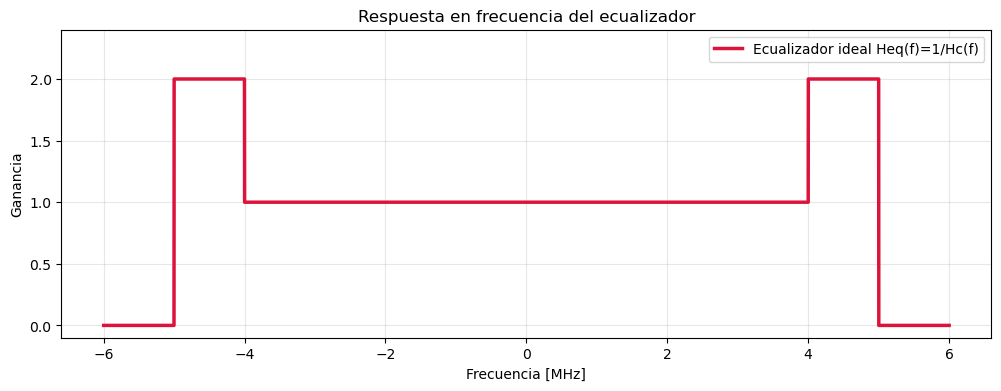

In [3]:
Heq = np.zeros_like(Hc)
banda_util = Hc > 0
Heq[banda_util] = 1 / Hc[banda_util]

plt.figure(figsize=(12, 4))
plt.plot(f/1e6, Heq, linewidth=2.5, color="crimson", label="Ecualizador ideal Heq(f)=1/Hc(f)")
plt.title("Respuesta en frecuencia del ecualizador")
plt.xlabel("Frecuencia [MHz]")
plt.ylabel("Ganancia")
plt.ylim(-0.1, 2.4)
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

## Conclusion

La maxima tasa de simbolos que entra dentro de la banda no nula del canal usando coseno realzado con `beta = 0.35` es:

$$R_{s,max}\approx 7.407\;\text{Msimb/s}$$

Con esa tasa, la senal ocupa hasta `5 MHz`, por lo que aprovecha toda la banda disponible del canal. Sin embargo, como el canal vale `0.5` entre `4 MHz` y `5 MHz`, existe distorsion lineal: algunas componentes frecuenciales llegan con menor amplitud que otras.

Para compensar esa distorsion, se modifica el receptor agregando un ecualizador con respuesta inversa al canal dentro de la banda usada. En este caso, el ecualizador debe tener ganancia `1` hasta `4 MHz` y ganancia `2` entre `4 MHz` y `5 MHz`. Asi, el producto canal-ecualizador queda aproximadamente plano y la respuesta total vuelve a cumplir el criterio de Nyquist.

Si no se quisiera ecualizar, entonces habria que limitar la senal a la zona plana del canal, hasta `4 MHz`, y la tasa maxima bajaria a aproximadamente `5.926 Msimb/s`.